In [51]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
import re 
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [81]:
results_pkls

[PosixPath('parameter_decoding/resnet18_barlow_invariant_only_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_1e-02/avgpool_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_invariant_only_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_5e-01/layer3_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_invariant_only_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_5e-01/layer2_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_invariant_only_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_resnet18_barlow_equivariant_lmbda_1e-2_lr_2e-1_no_avgpool_eq_lmbda_5e-01/layer4_r2_decoding_values.pkl'),
 PosixPath('parameter_decoding/resnet18_barlow_invariant_only_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_resnet18_barlow_equ

'_lmbda_1e-2_lr_2e-1_w_invar_augment_no_avgpool_eq_lmbda_1'

In [144]:
### Get results from dir

param_decoding_results_dir = Path("parameter_decoding")
results_pkls = list(param_decoding_results_dir.rglob("*_r2_decoding_values.pkl"))

results_dfs = []
for file_path in results_pkls:
    results_dict = pd.read_pickle(file_path)
    if 'pr2_invariant' not in results_dict.keys():
        continue 

    results_df = pd.DataFrame.from_dict(results_dict)
    results_df['parameter'] = results_df.index
    results_df.reset_index(drop=True)
    results_df['layer'] = file_path.stem.split('_r2')[0]
    results_df['eq_lmbda'] = float(file_path.parent.stem.split('eq_lmbda_')[-1])
    eq_model_base_name = file_path.parent.stem.split('equivariant_')[-1]
    results_df['augmentations'] = 'invariant' if 'w_invar_augment' in eq_model_base_name else "equivariant"
    results_dfs.append(results_df)
    # break

results = pd.concat(results_dfs, axis=0, ignore_index = True)

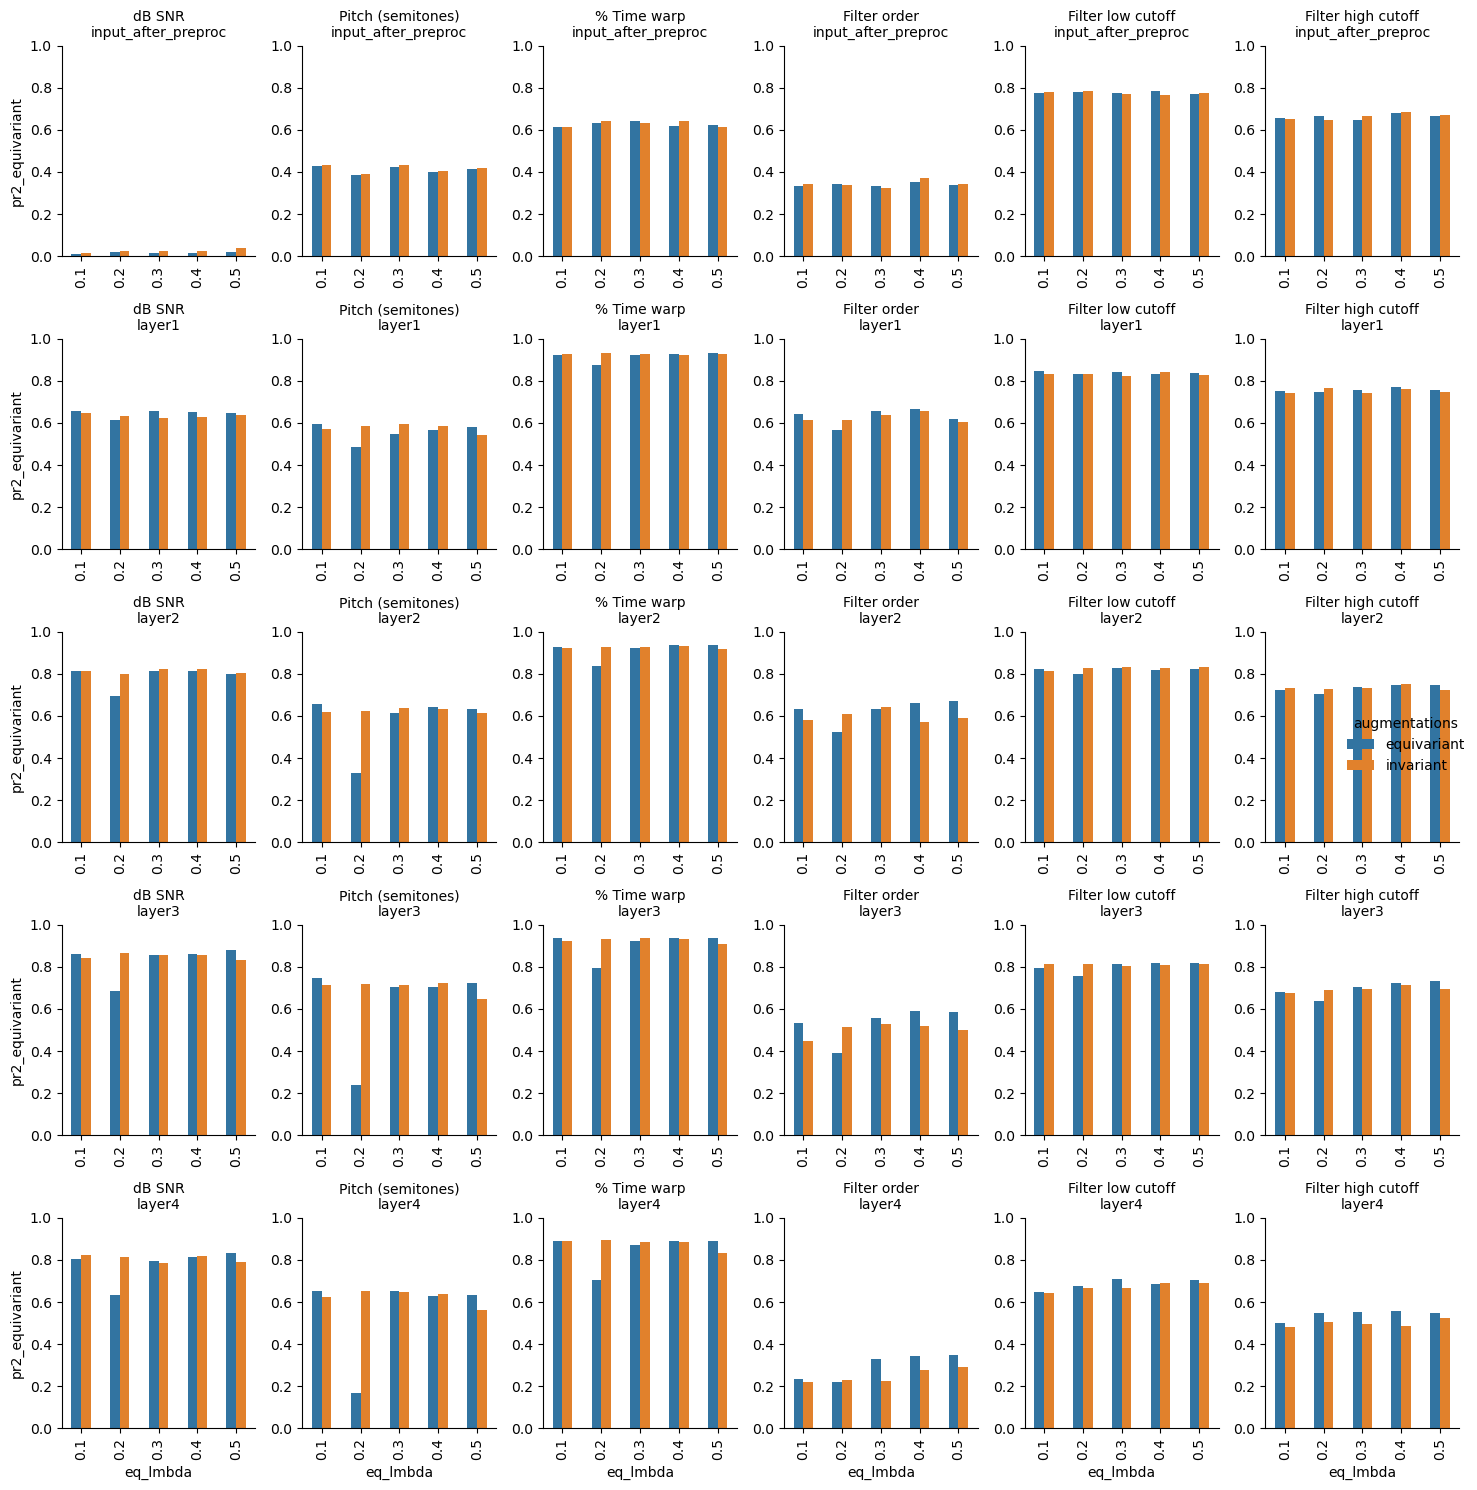

In [145]:
layer_order = [
            'input_after_preproc',
            'layer1',
            'layer2', 
            'layer3',
            'layer4',
            # 'avgpool'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())

g = sns.catplot(data=results,
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='pr2_equivariant', 
            hue='augmentations', 
            col='parameter',
            row='layer', 
            row_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=0.75)

g.set_titles("{col_name}\n{row_name}")
g.set(ylim=(0,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
plt.tight_layout()


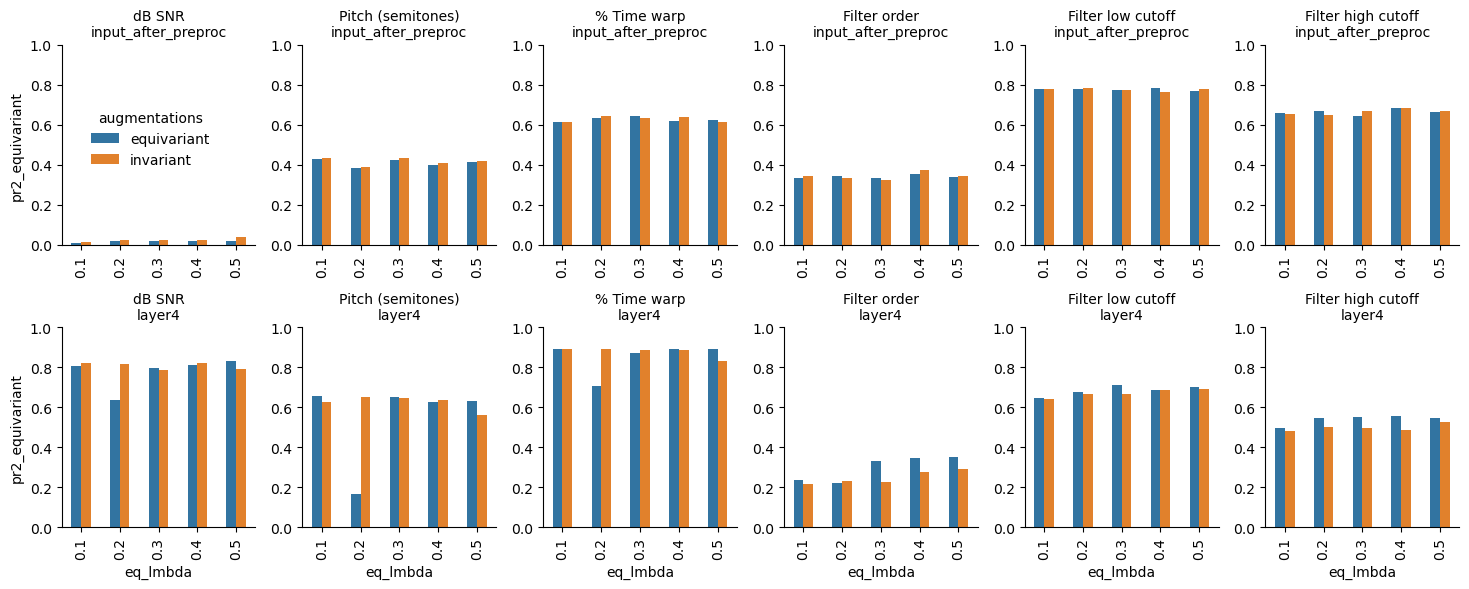

In [161]:
layer_order = [
            'input_after_preproc',
            # 'layer1',
            # 'layer2', 
            # 'layer3',
            'layer4',
            # 'avgpool'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())

g = sns.catplot(data=results,
            kind = 'bar',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='pr2_equivariant', 
            hue='augmentations', 
            col='parameter',
            row='layer', 
            row_order=layer_order,
            sharey=False,
            sharex=False,
            width=0.5,
            height=3, aspect=0.75)

g.set_titles("{col_name}\n{row_name}")
g.set(ylim=(0,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)
# Access the legend object
leg = g._legend

# Set the legend's position (adjust the coordinates as needed)
leg.set_bbox_to_anchor([0.15, 0.75])
plt.tight_layout()


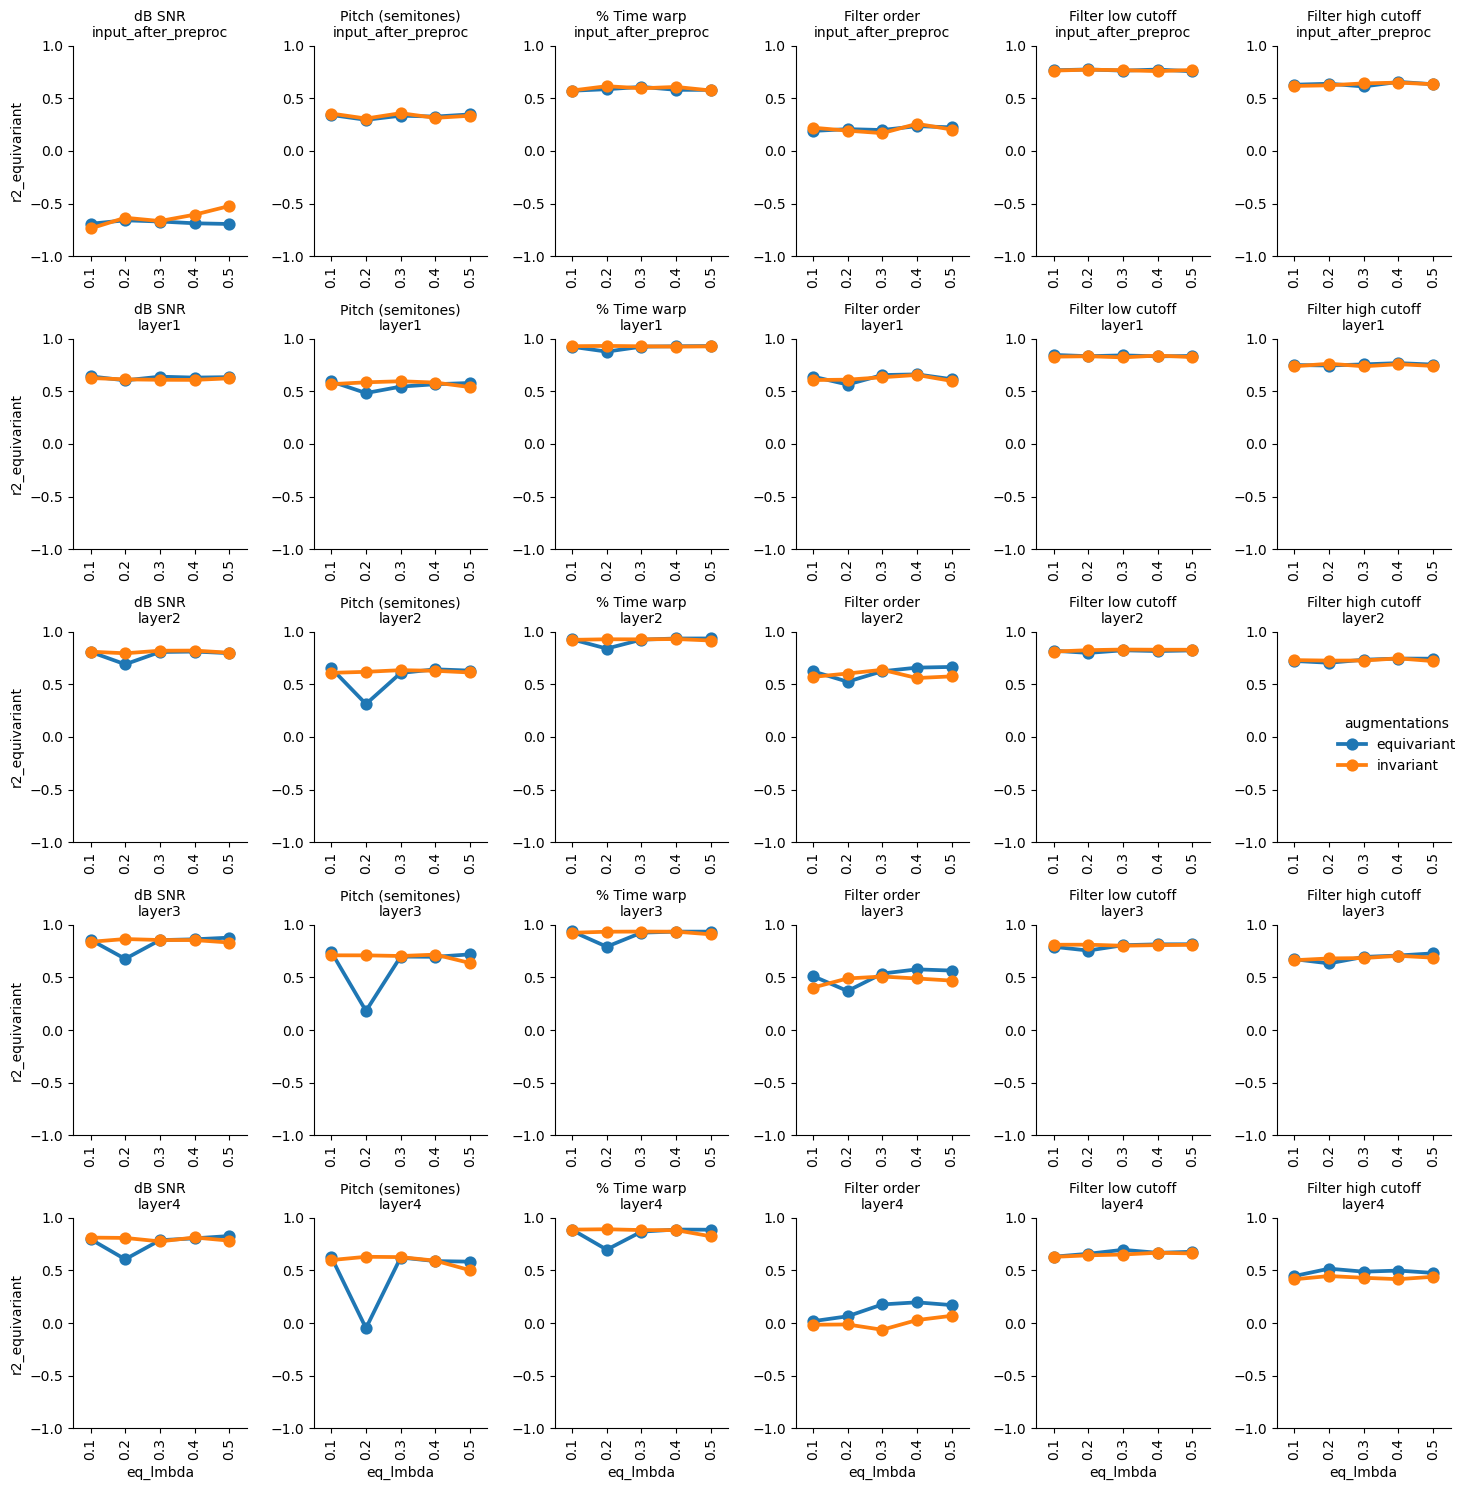

In [152]:
layer_order = [
            'input_after_preproc',
            'layer1',
            'layer2', 
            'layer3',
            'layer4',
            # 'avgpool'
]

eq_lmbda_order = sorted(results['eq_lmbda'].unique())

g = sns.catplot(data=results,
            kind = 'point',
            x='eq_lmbda', 
            order=eq_lmbda_order,
            y='r2_equivariant', 
            hue='augmentations', 
            col='parameter',
            row='layer', 
            row_order=layer_order,
            sharey=False,
            sharex=False,
            # width=0.5,
            height=3, aspect=0.75)

g.set_titles("{col_name}\n{row_name}")
g.set(ylim=(-1,1))
g.set_xticklabels(labels=eq_lmbda_order, rotation=90)

plt.tight_layout()
